In [1]:
import pandas as pd 
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv('synthesis_dataset_extended_with_trends.csv')


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42900 entries, 0 to 42899
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          42900 non-null  object 
 1   Crop_Type     42900 non-null  object 
 2   Soil_Type     42900 non-null  object 
 3   Soil_pH       42900 non-null  float64
 4   Temperature   42900 non-null  float64
 5   Humidity      42900 non-null  float64
 6   Wind_Speed    42900 non-null  float64
 7   N             42900 non-null  float64
 8   P             42900 non-null  float64
 9   K             42900 non-null  float64
 10  Crop_Yield    42900 non-null  float64
 11  Soil_Quality  42900 non-null  float64
dtypes: float64(9), object(3)
memory usage: 3.9+ MB


In [4]:
df.head()

,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
0,2014-01-01,Wheat,Peaty,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333
1,2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
2,2014-01-01,Rice,Peaty,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333
3,2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
4,2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667


In [5]:

df['Date']=pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)

In [6]:
df=df.select_dtypes(include=['number'])

In [7]:
df=df.resample('D').mean()


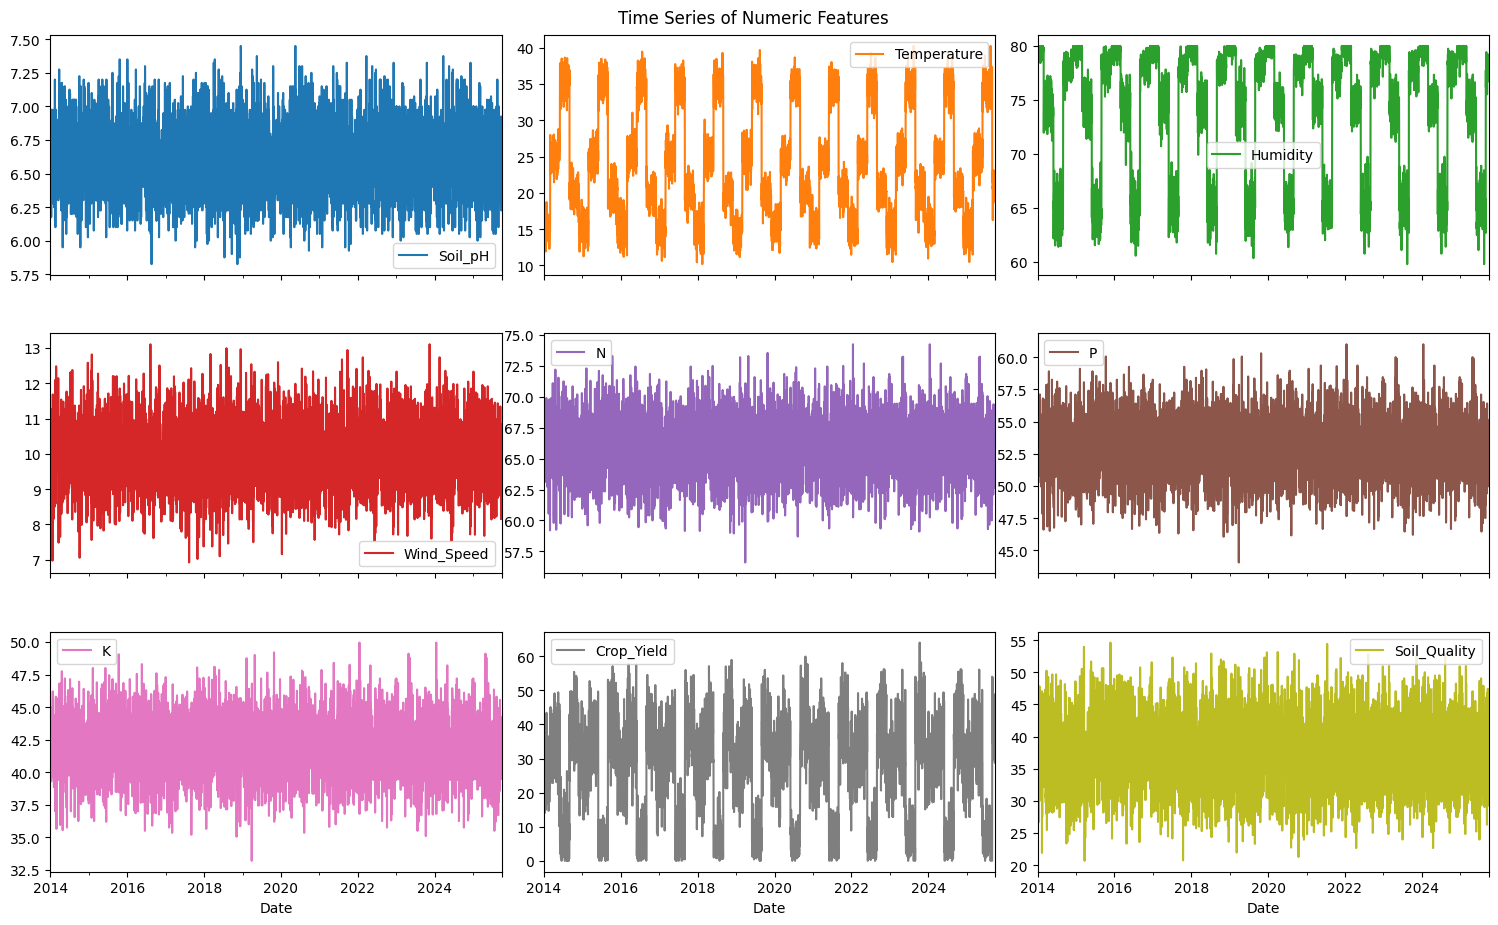

In [8]:
num_cols = ['Soil_pH','Temperature','Humidity','Wind_Speed',
            'N','P','K','Crop_Yield','Soil_Quality']


df[num_cols].plot(subplots=True, layout=(4,3), figsize=(15,12), title="Time Series of Numeric Features")
plt.tight_layout()
plt.show()

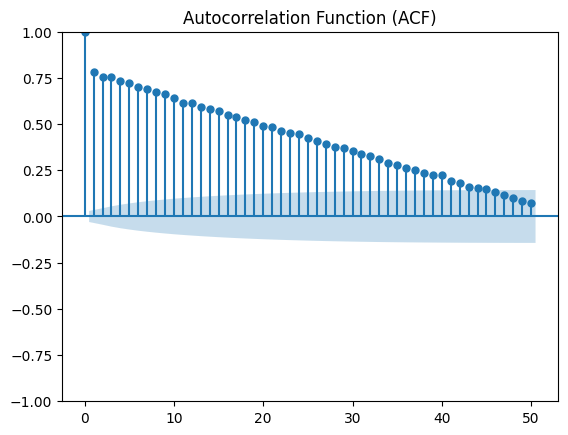

C:\Users\Kruthika Akkamgari\AppData\Roaming\Python\Python310\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


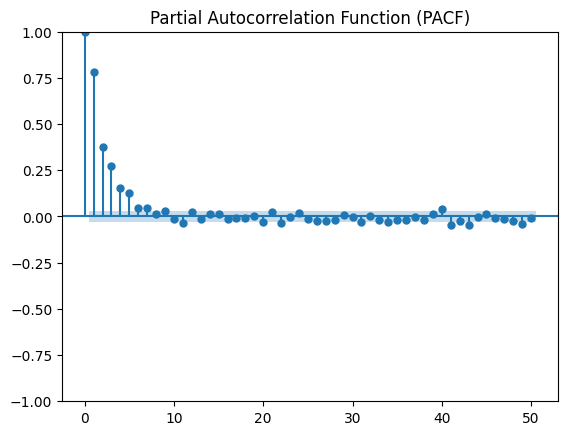

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


y= df['Crop_Yield']

# Plot ACF and PACF
plot_acf(y, lags=50)
plt.title('Autocorrelation Function (ACF)')
plt.show()

plot_pacf(y, lags=50)
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller
# Perform ADF test
adf_test = adfuller(y)

print(f'ADF Statistic: {adf_test[0]}')
print(f'p-value: {adf_test[1]}')
print('Critical Values:')
for key, value in adf_test[4].items():
    print(f'\t{key}: {value}')

ADF Statistic: -6.828599398690238
p-value: 1.9192953093747215e-09
Critical Values:
	1%: -3.4318795063432592
	5%: -2.8622158513096414
	10%: -2.567129760779626


In [12]:

exog_vars=['Soil_pH','Temperature','Humidity','Wind_Speed',
            'N','P','K','Soil_Quality']
exog=df[exog_vars]

In [13]:
from statsmodels.tsa.arima.model import ARIMA
model_multi=ARIMA(df['Crop_Yield'],exog,order=(1,0,1)).fit()
forecast_steps = 7
forecast_multi = model_multi.forecast(steps=forecast_steps, exog=exog.tail(forecast_steps))
print(f"Generated forecast for {forecast_steps} steps.")
forecast_multi

Generated forecast for 7 steps.


2025-09-30    46.764915
2025-10-01    40.638407
2025-10-02    41.716244
2025-10-03    38.716746
2025-10-04    38.851464
2025-10-05    39.652168
2025-10-06    35.198269
Freq: D, Name: predicted_mean, dtype: float64

RMSE: 25.53892524909474, MAE: 3.8721494189742307


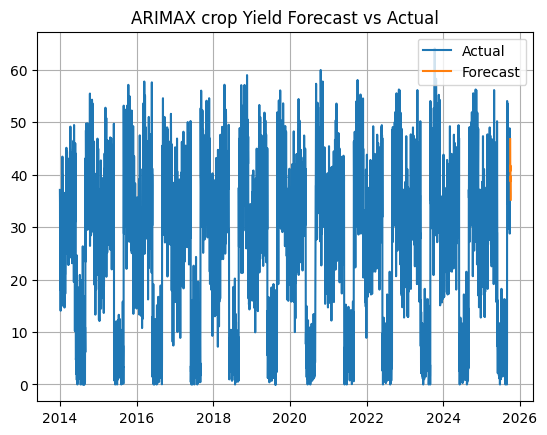

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
actual = df['Crop_Yield'][-7:]  
rmse = mean_squared_error(actual, forecast_multi)
mae = mean_absolute_error(actual, forecast_multi)
print(f'RMSE: {rmse}, MAE: {mae}')
plt.plot(df.index,df['Crop_Yield'],label='Actual')
plt.plot(forecast_multi.index,forecast_multi,label='Forecast')
plt.legend()
plt.grid()
plt.title('ARIMAX crop Yield Forecast vs Actual')
plt.show()

In [18]:
import pickle  

# Save the model
pickle.dump(model_multi, open("timeseries_model.pkl", "wb"))
